<a href="https://colab.research.google.com/github/botirbekzulf-sudo/ML/blob/main/%D0%A3%D1%80%D0%BE%D0%BA14_%D1%81%D0%B0%D0%BC%D0%BE%D1%81%D1%82%D0%BE%D1%8F%D1%82%D0%B5%D0%BB%D1%8C%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔢 Урок 14 — Самостоятельная работа: сеть узнаёт цифры

### Как работать
Читай · запускай по порядку · выполняй задания 📝 · отвечай словами ✍️.

> 🎯 К концу урока ты обучишь сеть распознавать рукописные цифры и напишешь свою.

*Обучение занимает ~1 минуту. Ничего устанавливать не нужно.*

## Шаг 1 · Картинка — это числа
Запусти и посмотри: слева цифра, справа — те же данные числами.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


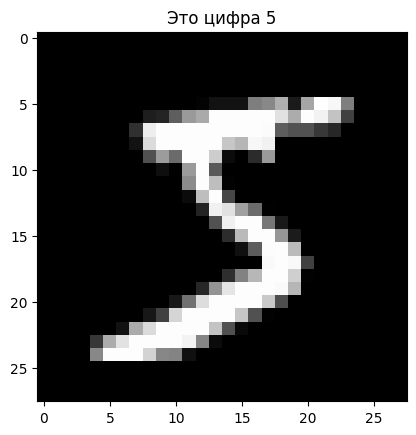

Для компьютера это числа 0..255:
[[  1 154 253  90   0   0]
 [  0 139 253 190   2   0]
 [  0  11 190 253  70   0]
 [  0   0  35 241 225 160]
 [  0   0   0  81 240 253]
 [  0   0   0   0  45 186]]


In [1]:
from tensorflow import keras
import matplotlib.pyplot as plt
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()
plt.imshow(X_train[0], cmap='gray'); plt.title(f'Это цифра {y_train[0]}'); plt.show()
print('Для компьютера это числа 0..255:')
print(X_train[0][10:16, 10:16])

✍️ **Ответь.** Что значат числа в матрице? (Подсказка: 0 — чёрный, 255 — белый.)

*Ответ:* … зто цвет

## Шаг 2 · Собираем и обучаем сеть
Запусти. Сеть учится узнавать цифры (~1 мин).

In [2]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0
model = keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=3, validation_split=0.1)
_, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Точность на новых цифрах: {test_acc:.1%}')

Epoch 1/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9214 - loss: 0.2714 - val_accuracy: 0.9640 - val_loss: 0.1251
Epoch 2/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9630 - loss: 0.1236 - val_accuracy: 0.9725 - val_loss: 0.0910
Epoch 3/3
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9740 - loss: 0.0849 - val_accuracy: 0.9760 - val_loss: 0.0828
Точность на новых цифрах: 97.5%


## Шаг 3 · Где сеть ошибается?

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 962us/step


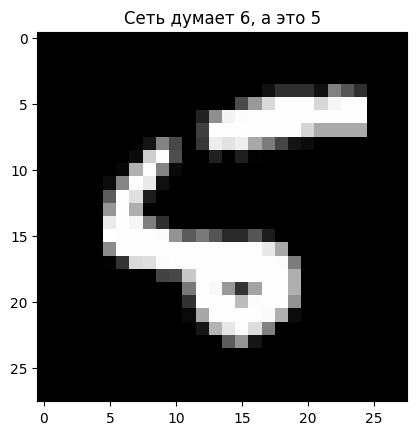

In [3]:
import numpy as np
pred = np.argmax(model.predict(X_test), axis=1)
errors = np.where(pred != y_test)[0]
i = errors[0]
plt.imshow(X_test[i], cmap='gray'); plt.title(f'Сеть думает {pred[i]}, а это {y_test[i]}'); plt.show()

### 📝 Задание — поэкспериментируй
Меняй число нейронов и эпох. Больше — всегда лучше?

In [7]:
units = 128    # 👈 меняй (32, 128, 512)
epochs = 5     # 👈 меняй (1, 3, 5)
net = keras.Sequential([keras.Input(shape=(28,28)), keras.layers.Flatten(),
    keras.layers.Dense(units, activation='relu'),
    keras.layers.Dense(10, activation='softmax')])
net.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
net.fit(X_train, y_train, epochs=epochs, verbose=0)
_, a = net.evaluate(X_test, y_test, verbose=0)
print(f'{units} нейронов, {epochs} эпох -> точность {a:.1%}')

128 нейронов, 5 эпох -> точность 97.7%


## Шаг 4 · Честный разговор: сеть на шуме
Покажем сети случайный шум. Что она ответит?

In [11]:
import numpy as np
noise = np.random.rand(1,28,28)
probs = model.predict(noise)[0]
print(f'На шуме сеть уверенно говорит: {np.argmax(probs)} (уверенность {probs.max():.0%})')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
На шуме сеть уверенно говорит: 5 (уверенность 100%)


✍️ **Ответь.** Сеть уверенно назвала цифру на мусоре. Чем это опасно?

*Ответ:* …

## ✅ Проверь себя
1. Что «видит» сеть вместо картинки?
2. Зачем делить на 255?
3. Почему сеть может уверенно ошибаться?

<details><summary>Ответы</summary>

1. Матрицу чисел (яркость пикселей).
2. Нормализация — числа 0..1, обучение идёт лучше.
3. Она ищет паттерны в пикселях, а не «понимает» — на незнакомом уверенно ошибается.
</details>

## 🏁 Финальное задание (для сильных)
Напиши свою цифру тёмным маркером, сфотографируй, загрузи и проверь, узнает ли сеть.

In [9]:
# Запусти в Colab: откроется окно загрузки файла
from google.colab import files
from PIL import Image
import numpy as np
uploaded = files.upload()
name = list(uploaded.keys())[0]
img = Image.open(name).convert('L').resize((28,28))
img = 255 - np.array(img)      # инверсия: цифра должна быть светлой на тёмном
p = np.argmax(model.predict((img/255.0).reshape(1,28,28)))
print(f'Сеть думает, что вы написали: {p}')

Saving 9.png to 9.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Сеть думает, что вы написали: 9


In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

model = Sequential([
    Flatten(input_shape=(28, 28)),        # картинка -> 784 числа
    Dense(128, activation="relu"),        # скрытый слой
    Dense(10, activation="softmax"),      # 10 цифр: вероятности
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Обучаем 5 эпох
model.fit(X_train, y_train, epochs=5)

# Проверяем на тесте, которого сеть не видела
loss, acc = model.evaluate(X_test, y_test)
print("Точность на тесте:", round(acc, 3))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9269 - loss: 0.2579
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9653 - loss: 0.1168
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9754 - loss: 0.0810
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9815 - loss: 0.0611
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9852 - loss: 0.0481
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9724 - loss: 0.0886
Точность на тесте: 0.972


---
### 🎉 Готово!
Ты обучил сеть, которая читает рукописные цифры — и увидел, что она не «понимает», а находит паттерны. Дальше научим её «видеть» формы (свёрточные сети).